# 05 Results & Analysis
Analyses the cascade randomisation scores from Notebook 04: degradation curves per method, per-pathology breakdown, Spearman/SSIM agreement, and distribution at full randomisation - building toward the analysis in `results.md`.

#### Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the raw similarity scores and split into the main (trained-vs-randomised) and null (random-vs-random) comparisons
results_df = pd.read_csv('../results/sanity_check_scores.csv')
main = results_df[results_df['comparison'] == 'trained_vs_randomised']
null = results_df[results_df['comparison'] == 'random_vs_random_null']

**Primary result:** Mean Spearman correlation to the trained baseline, per method, across randomisation depth. Dashed lines show each method's random-vs-random null - a method whose curve approaches its null line has effectively lost all dependence on learned weights (sanity check fails); a method that drops well below it has degraded (sanity check passes).

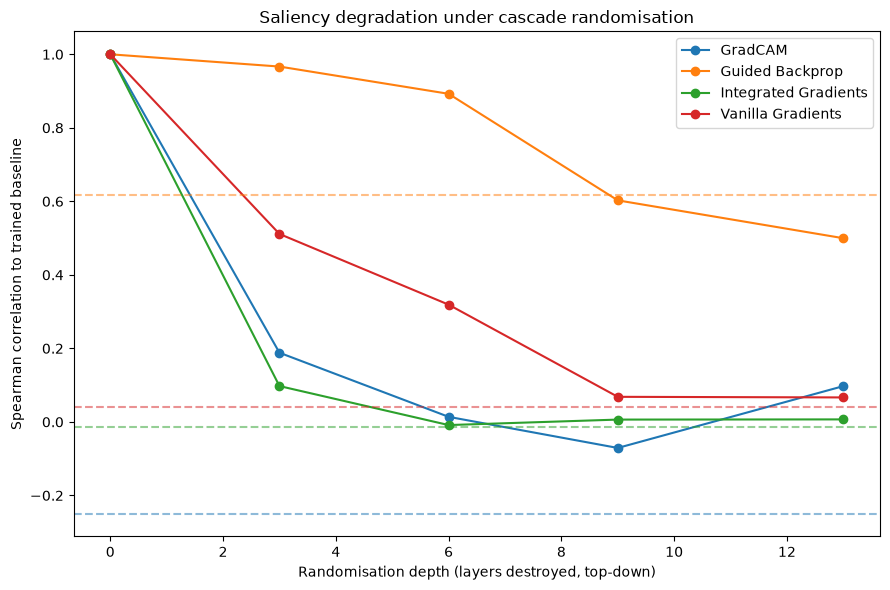

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

color_map = {}
for method_name, group in main.groupby('method'):
    depth_means = group.groupby('depth')['spearman'].mean()
    line, = ax.plot(depth_means.index, depth_means.values, marker='o', label=method_name)
    color_map[method_name] = line.get_color()

for method_name, group in null.groupby('method'):
    ax.axhline(group['spearman'].mean(), linestyle='--', alpha=0.5, color=color_map[method_name])

ax.set_xlabel('Randomisation depth (layers destroyed, top-down)')
ax.set_ylabel('Spearman correlation to trained baseline')
ax.set_title('Saliency degradation under cascade randomisation')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/degradation_curves.png', dpi=150)
plt.show()

Numeric summary of the plot above: mean Spearman correlation by method and depth, and each method's null-comparison baseline.

In [11]:
print(main.groupby(['method', 'depth'])['spearman'].mean().unstack())
print(null.groupby('method')['spearman'].mean())

depth                  0         3         6         9         13
method                                                           
GradCAM               1.0  0.188224  0.013830 -0.070837  0.097361
Guided Backprop       1.0  0.966666  0.892518  0.602687  0.499700
Integrated Gradients  1.0  0.097512 -0.008567  0.006317  0.006833
Vanilla Gradients     1.0  0.511297  0.318956  0.068242  0.066592
method
GradCAM                -0.249238
Guided Backprop         0.617196
Integrated Gradients   -0.012801
Vanilla Gradients       0.041007
Name: spearman, dtype: float64


**Per-pathology degradation:** Splits the aggregate degradation curve by pathology, checking whether sanity-check pass/fail behaviour varies with how localised or subtle a pathology's typical finding is.

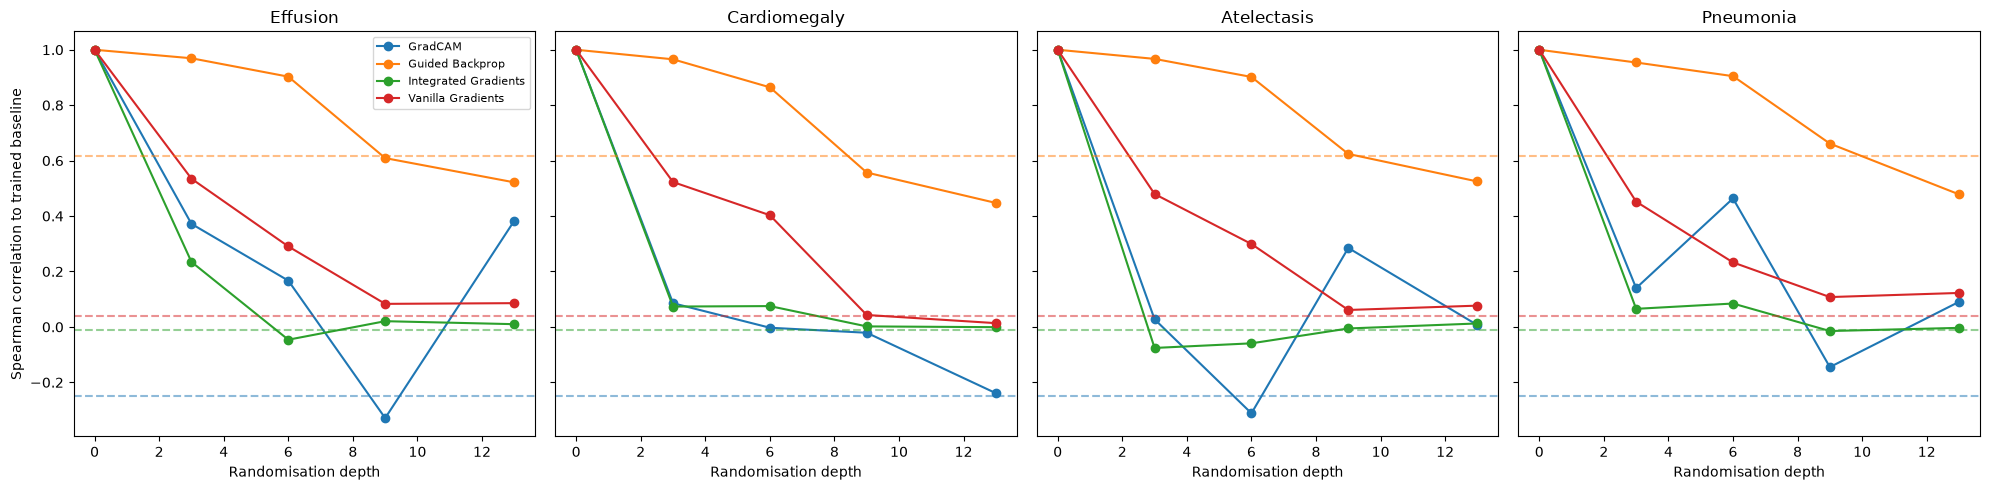

In [19]:
pathologies_present = main['pathology'].unique()
fig, axes = plt.subplots(1, len(pathologies_present), figsize=(5 * len(pathologies_present), 5), sharey=True)

color_map = {}
for ax, pathology in zip(axes, pathologies_present):
    subset = main[main['pathology'] == pathology]
    for method_name, group in subset.groupby('method'):
        depth_means = group.groupby('depth')['spearman'].mean()
        line, = ax.plot(depth_means.index, depth_means.values, marker='o', label=method_name)
        color_map[method_name] = line.get_color()

    for method_name, group in null.groupby('method'):
        ax.axhline(group['spearman'].mean(), linestyle='--', alpha=0.5, color=color_map[method_name])

    ax.set_title(pathology)
    ax.set_xlabel('Randomisation depth')

axes[0].set_ylabel('Spearman correlation to trained baseline')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/degradation_curves_by_pathology.png', dpi=150)
plt.show()

**Spearman vs. SSIM comparison:** Checks whether the two similarity metrics agree on which methods pass/fail the sanity check - a robustness check against either metric being a quirk of what it measures (rank correlation vs. structural similarity).

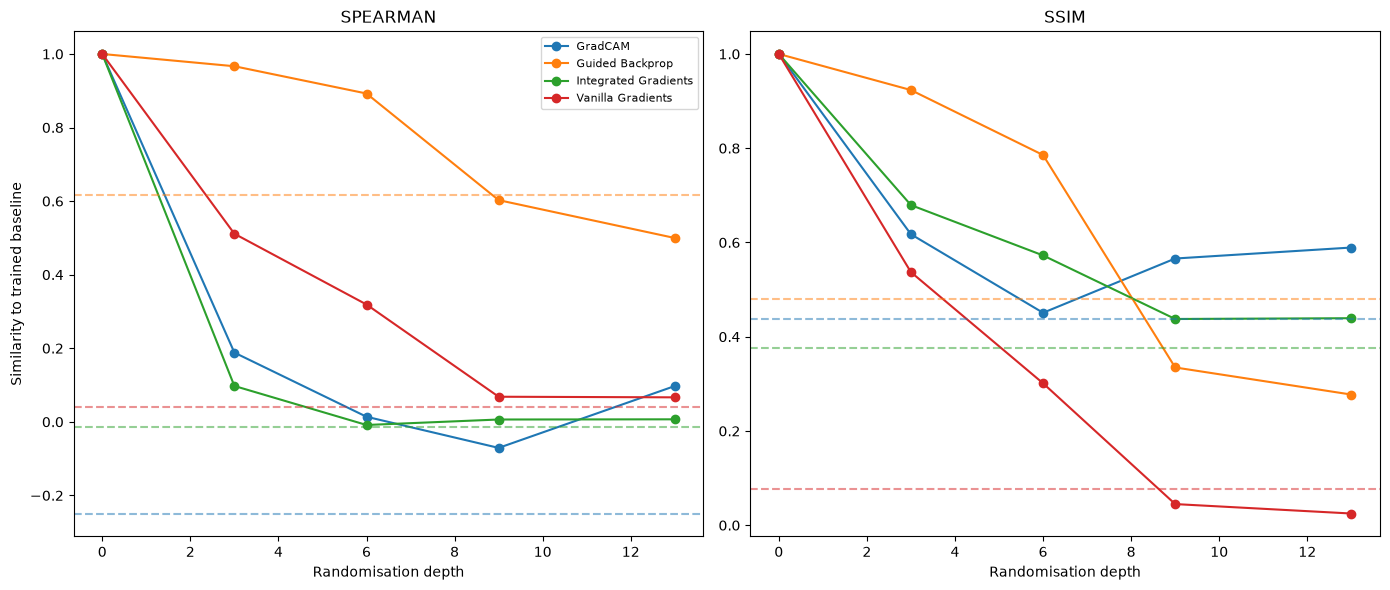

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for metric, ax in zip(['spearman', 'ssim'], axes):
    color_map = {}
    for method_name, group in main.groupby('method'):
        depth_means = group.groupby('depth')[metric].mean()
        line, = ax.plot(depth_means.index, depth_means.values, marker='o', label=method_name)
        color_map[method_name] = line.get_color()

    for method_name, group in null.groupby('method'):
        ax.axhline(group[metric].mean(), linestyle='--', alpha=0.5, color=color_map[method_name])
    ax.set_xlabel('Randomisation depth')
    ax.set_title(metric.upper())

axes[0].set_ylabel('Similarity to trained baseline')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/degradation_curves_spearman_vs_ssim.png', dpi=150)
plt.show()

**Spread at full randomisation:** Shows the distribution across individual images (not just the mean) at maximum randomisation depth - important given the small sample size, since a mean alone can hide substantial per-image variation.

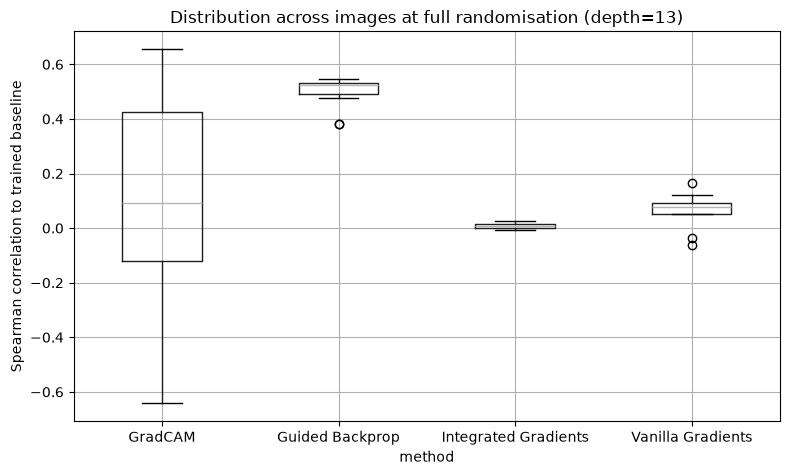

In [14]:
final_depth = main['depth'].max()
final_scores = main[main['depth'] == final_depth]

fig, ax = plt.subplots(figsize=(8, 5))
final_scores.boxplot(column='spearman', by='method', ax=ax)
ax.set_ylabel('Spearman correlation to trained baseline')
ax.set_title(f'Distribution across images at full randomisation (depth={final_depth})')
plt.suptitle('')
plt.tight_layout()
plt.savefig('../figures/final_depth_distribution.png', dpi=150)
plt.show()

See `results.md` for the full interpretation: which methods pass/fail the sanity check, pathology-level variation, and documented limitations.